# Exploratory Data Analysis — Room 2.3

This notebook presents the exploratory data analysis (EDA) of the final integrated dataset for Room 2.3.

The analysis includes dataset validation, descriptive statistics, indoor air quality characteristics, occupancy patterns, sensor behavior, temporal patterns, and relationships among the main environmental and occupancy-related variables.

In [1]:
# IMPORTS AND NOTEBOOK CONFIGURATION


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew


# Plot configuration
plt.style.use("default")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11


# Pandas display configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

## 1. Dataset Loading

The final integrated dataset for Room 2.3 is loaded and the timestamp column is converted to datetime format. An initial inspection is performed to verify the dataset dimensions and structure.


In [2]:
# LOAD FINAL DATASET — ROOM 2.3


# Load the final integrated dataset
df = pd.read_csv("room_2_3_final.csv")

# Convert timestamp column to datetime
df["ts"] = pd.to_datetime(df["ts"])

# Initial verification
print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

display(df.head())

Dataset loaded successfully!
Rows: 38645
Columns: 10


,ts,co2,temperature,humidity,light_level,pir,people_count_all,people_count_max,region_count,open_windows_all
0,2025-09-01 14:40:00,544.0,29.9,37.5,1.0,0,0,2,0,1
1,2025-09-01 14:50:00,544.0,29.9,37.5,1.0,1,0,2,0,1
2,2025-09-01 15:00:00,543.0,29.9,37.5,1.0,0,0,2,0,1
3,2025-09-01 15:10:00,543.0,29.9,37.5,1.0,0,0,2,0,1
4,2025-09-01 15:20:00,544.0,29.9,37.5,1.0,0,0,2,0,1


## 2. Dataset Overview

This section provides an overview of the final Room 2.3 dataset, including its dimensions, variables, data types, memory usage, and temporal coverage.

In [3]:
# DATASET OVERVIEW


print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"\nRows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMemory usage:")
print(f"{df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\nTime coverage:")
print(f"Start: {df['ts'].min()}")
print(f"End:   {df['ts'].max()}")

print("\nUnique timestamps:")
print(df["ts"].nunique())

DATASET OVERVIEW

Rows: 38645
Columns: 10

Column names:
['ts', 'co2', 'temperature', 'humidity', 'light_level', 'pir', 'people_count_all', 'people_count_max', 'region_count', 'open_windows_all']

Data types:


,0
ts,datetime64[ns]
co2,float64
temperature,float64
humidity,float64
light_level,float64
pir,int64
people_count_all,int64
people_count_max,int64
region_count,int64
open_windows_all,int64



Memory usage:
2.95 MB

Time coverage:
Start: 2025-09-01 14:40:00
End:   2026-05-27 23:20:00

Unique timestamps:
38645


## 3. Data Quality Assessment

Before performing the exploratory analysis, the dataset is checked for missing values, duplicate observations, duplicate timestamps, and the valid states of selected discrete sensor variables.


In [4]:
# DATA QUALITY ASSESSMENT


print("=" * 60)
print("DATA QUALITY ASSESSMENT")
print("=" * 60)

print("\nMissing values:")
display(df.isna().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nDuplicate timestamps:")
print(df["ts"].duplicated().sum())

print("\nUnique PIR values:")
print(sorted(df["pir"].unique()))

print("\nUnique open-window values:")
print(sorted(df["open_windows_all"].unique()))

print("\nUnique region-count values:")
print(sorted(df["region_count"].unique()))

DATA QUALITY ASSESSMENT

Missing values:


,0
ts,0
co2,0
temperature,0
humidity,0
light_level,0
pir,0
people_count_all,0
people_count_max,0
region_count,0
open_windows_all,0



Duplicate rows:
0

Duplicate timestamps:
0

Unique PIR values:
[np.int64(0), np.int64(1)]

Unique open-window values:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Unique region-count values:
[np.int64(0)]


In [5]:
# DESCRIPTIVE STATISTICS


numerical_columns = [
    "co2",
    "temperature",
    "humidity",
    "light_level",
    "people_count_all",
    "people_count_max",
    "open_windows_all"
]

stats = df[numerical_columns].describe().T

stats["median"] = df[numerical_columns].median()
stats["variance"] = df[numerical_columns].var()
stats["skewness"] = df[numerical_columns].apply(skew)

display(stats.round(3))

,count,mean,std,min,25%,50%,75%,max,median,variance,skewness
co2,38645.0,488.848,144.771,377.0,419.0,442.0,490.0,2317.0,442.0,20958.644,4.113
temperature,38645.0,22.341,2.762,17.1,20.1,21.8,24.0,29.9,21.8,7.628,0.762
humidity,38645.0,44.848,7.315,19.5,39.5,45.0,50.0,70.0,45.0,53.502,0.066
light_level,38645.0,0.721,0.918,0.0,0.0,0.0,1.0,3.0,0.0,0.843,0.989
people_count_all,38645.0,0.762,3.237,0.0,0.0,0.0,0.0,40.0,0.0,10.477,5.860
people_count_max,38645.0,1.674,4.545,0.0,0.0,0.0,1.0,44.0,0.0,20.660,4.053
open_windows_all,38645.0,1.251,0.978,0.0,1.0,1.0,2.0,5.0,1.0,0.956,0.704


## 4. Indoor Air Quality Analysis

The following analysis examines the distribution and temporal patterns of indoor CO₂ concentration in Room 2.3.

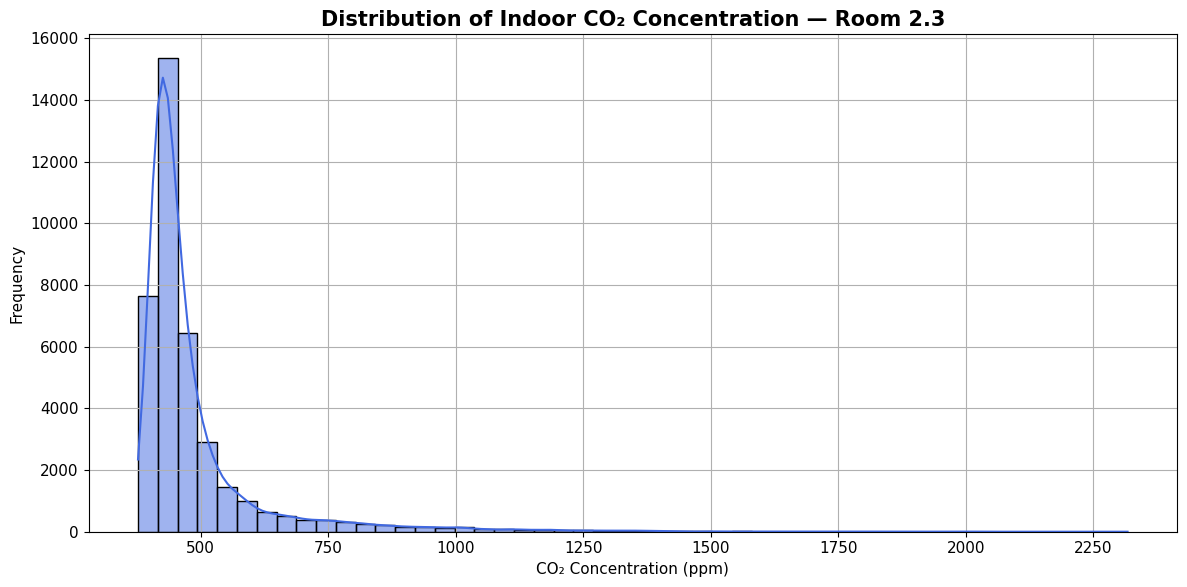

Saved: Figure_2_1_CO2_Distribution_Room_2_3.png


In [6]:
# ============================================================
# FIGURE 2.1 — CO₂ DISTRIBUTION
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(
    data=df,
    x="co2",
    bins=50,
    kde=True,
    color="royalblue",
    edgecolor="black",
    ax=ax
)

ax.set_title(
    "Distribution of Indoor CO₂ Concentration — Room 2.3",
    fontsize=15,
    weight="bold"
)

ax.set_xlabel("CO₂ Concentration (ppm)")
ax.set_ylabel("Frequency")

plt.tight_layout()

file_name = "Figure_2_1_CO2_Distribution_Room_2_3.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

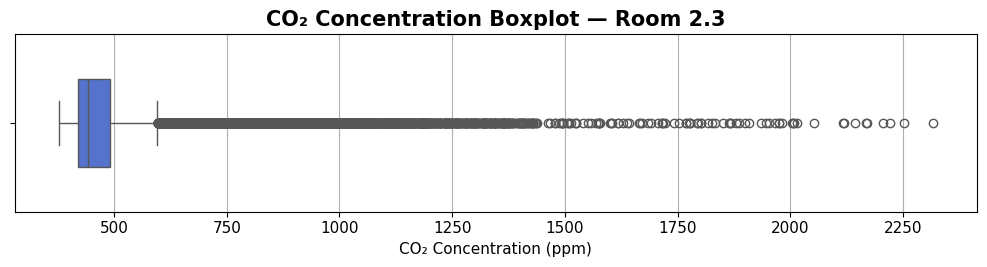

Saved: Figure_2_2_CO2_Boxplot_Room_2_3.png


In [7]:
# FIGURE 2.2 — CO₂ BOXPLOT

fig, ax = plt.subplots(figsize=(10, 2.8))

sns.boxplot(
    x=df["co2"],
    color="royalblue",
    width=0.5,
    ax=ax
)

ax.set_title(
    "CO₂ Concentration Boxplot — Room 2.3",
    fontsize=15,
    weight="bold"
)

ax.set_xlabel("CO₂ Concentration (ppm)")

plt.tight_layout()

file_name = "Figure_2_2_CO2_Boxplot_Room_2_3.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

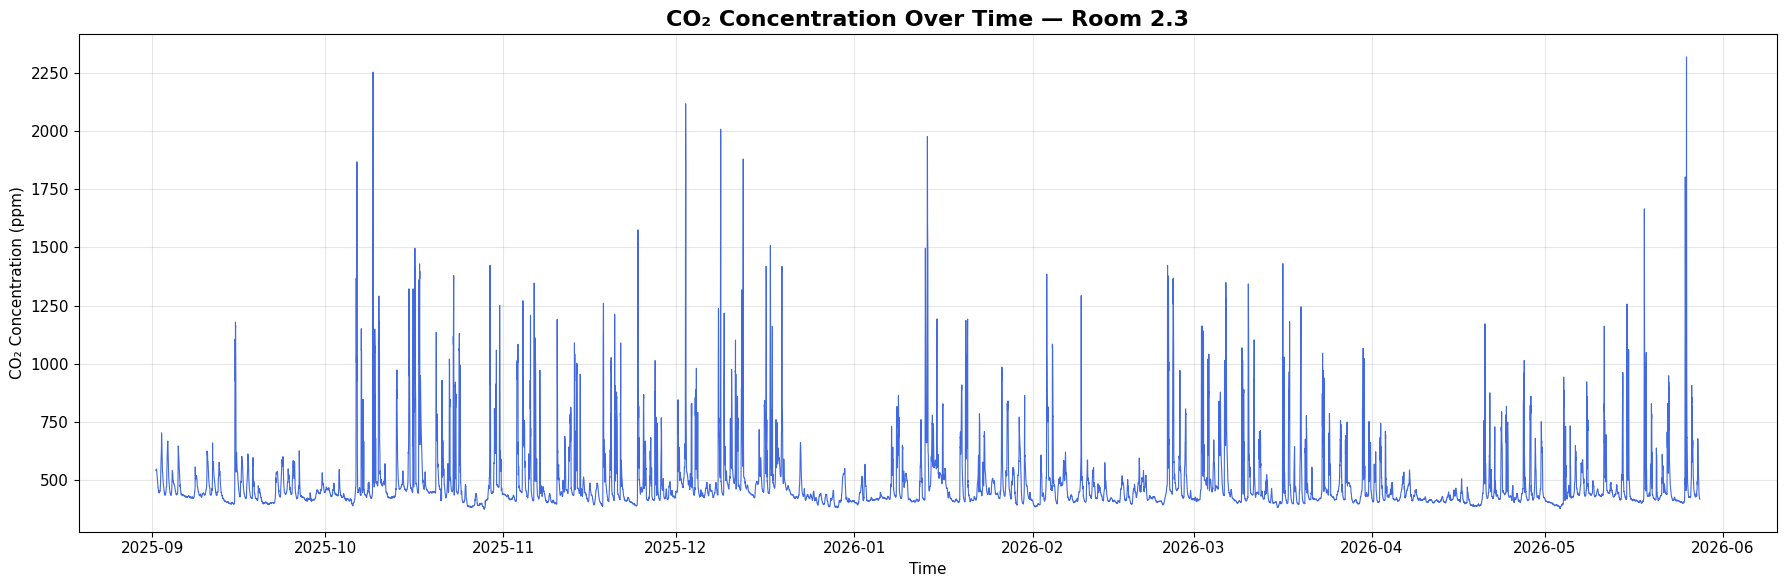

Saved: Figure_2_3_CO2_TimeSeries_Room_2_3.png


In [8]:
# FIGURE 2.3 — CO₂ TIME SERIES


fig, ax = plt.subplots(figsize=(18, 6))

ax.plot(
    df["ts"],
    df["co2"],
    color="royalblue",
    linewidth=0.8
)

ax.set_title(
    "CO₂ Concentration Over Time — Room 2.3",
    fontsize=16,
    weight="bold"
)

ax.set_xlabel("Time")
ax.set_ylabel("CO₂ Concentration (ppm)")

ax.grid(True, alpha=0.3)

plt.tight_layout()

file_name = "Figure_2_3_CO2_TimeSeries_Room_2_3.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

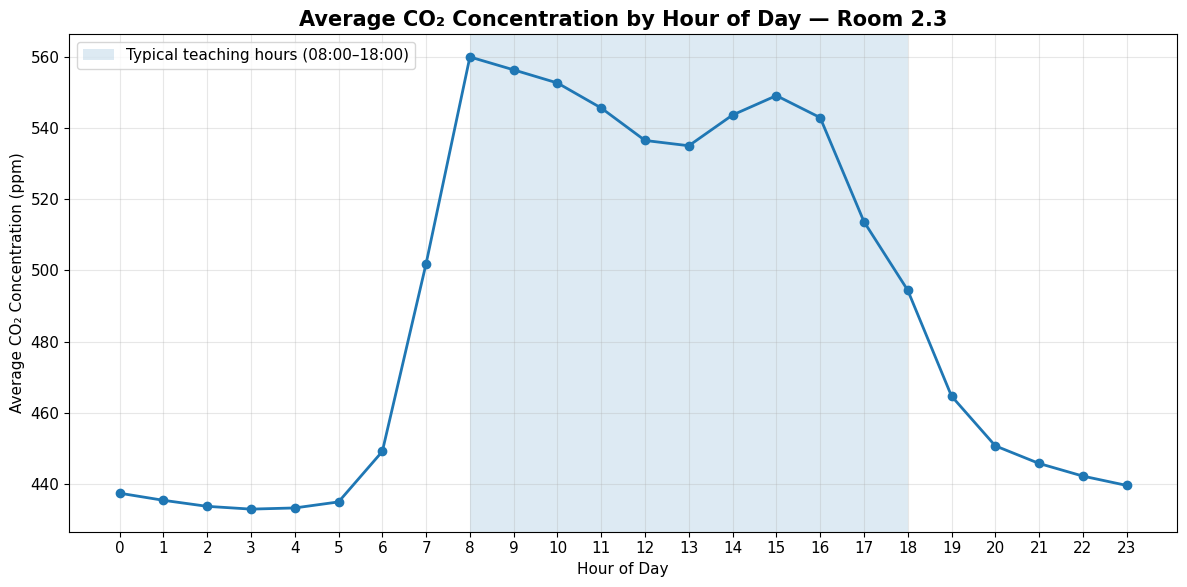

Saved: Figure_2_4_CO2_Hourly_Pattern_Room_2_3.png


In [9]:
# FIGURE 2.4 — AVERAGE CO₂ BY HOUR OF DAY


hourly_co2 = (
    df.assign(hour=df["ts"].dt.hour)
      .groupby("hour")["co2"]
      .mean()
      .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))

# Highlight typical teaching hours
ax.axvspan(
    8,
    18,
    alpha=0.15,
    label="Typical teaching hours (08:00–18:00)"
)

ax.plot(
    hourly_co2["hour"],
    hourly_co2["co2"],
    marker="o",
    linewidth=2
)

ax.set_title(
    "Average CO₂ Concentration by Hour of Day — Room 2.3",
    fontsize=15,
    weight="bold"
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average CO₂ Concentration (ppm)")

ax.set_xticks(range(24))
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()

file_name = "Figure_2_4_CO2_Hourly_Pattern_Room_2_3.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

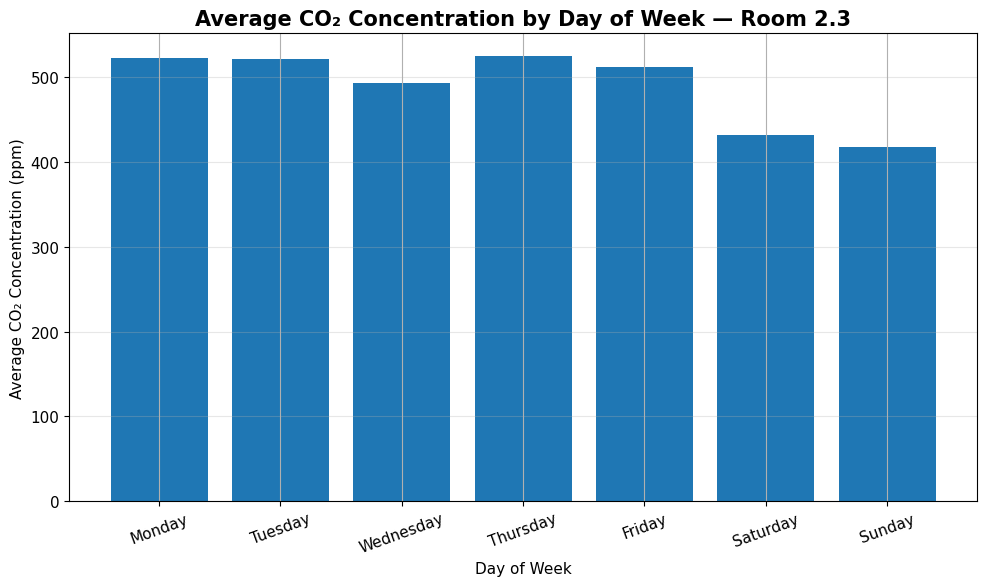

Saved: Figure_2_5_CO2_Weekly_Pattern_Room_2_3.png


In [10]:
# FIGURE 2.5 — AVERAGE CO₂ BY DAY OF WEEK


days_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekly_co2 = (
    df.assign(day=df["ts"].dt.day_name())
      .groupby("day")["co2"]
      .mean()
      .reindex(days_order)
      .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    weekly_co2["day"],
    weekly_co2["co2"]
)

ax.set_title(
    "Average CO₂ Concentration by Day of Week — Room 2.3",
    fontsize=15,
    weight="bold"
)

ax.set_xlabel("Day of Week")
ax.set_ylabel("Average CO₂ Concentration (ppm)")

plt.xticks(rotation=20)

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

file_name = "Figure_2_5_CO2_Weekly_Pattern_Room_2_3.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

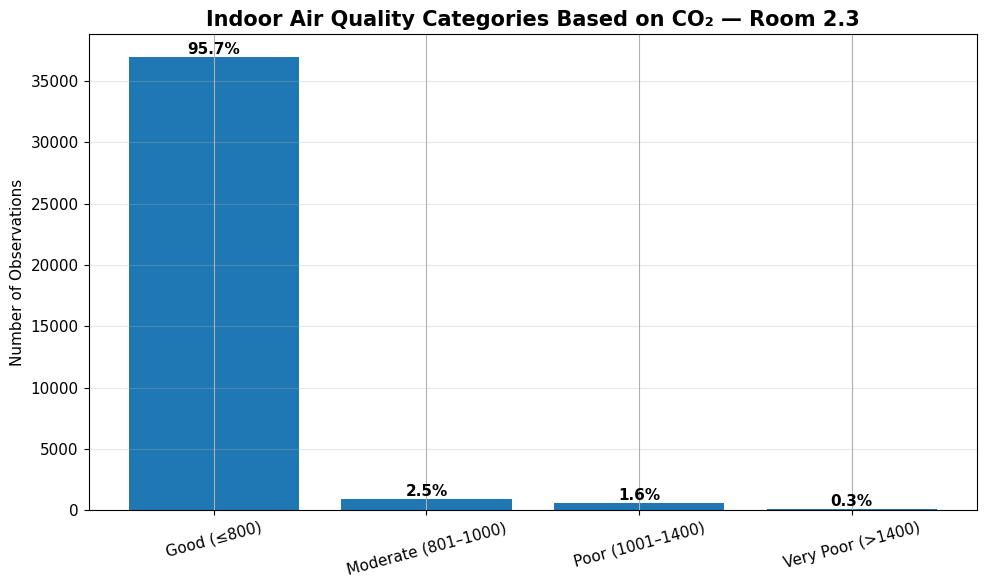

,Count,Percentage (%)
co2,,
Good (≤800),36974,95.68
Moderate (801–1000),952,2.46
Poor (1001–1400),608,1.57
Very Poor (>1400),111,0.29



Saved: Figure_2_6_CO2_Thresholds_Room_2_3.png


In [11]:
# FIGURE 2.6 — CO₂ AIR QUALITY CATEGORIES

co2_categories = pd.cut(
    df["co2"],
    bins=[0, 800, 1000, 1400, np.inf],
    labels=[
        "Good (≤800)",
        "Moderate (801–1000)",
        "Poor (1001–1400)",
        "Very Poor (>1400)"
    ]
)

category_counts = (
    co2_categories
    .value_counts()
    .sort_index()
)

category_percent = (
    category_counts /
    category_counts.sum() * 100
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    category_counts.index,
    category_counts.values
)

# Add percentage labels above each bar
for bar, pct in zip(bars, category_percent):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.set_title(
    "Indoor Air Quality Categories Based on CO₂ — Room 2.3",
    fontsize=15,
    weight="bold"
)

ax.set_ylabel("Number of Observations")

plt.xticks(rotation=15)

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

file_name = "Figure_2_6_CO2_Thresholds_Room_2_3.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

display(
    pd.DataFrame({
        "Count": category_counts,
        "Percentage (%)": category_percent.round(2)
    })
)

print(f"\nSaved: {file_name}")

## 5. Temperature and Humidity Analysis

This section examines the distributions of indoor temperature and relative humidity in Room 2.3.

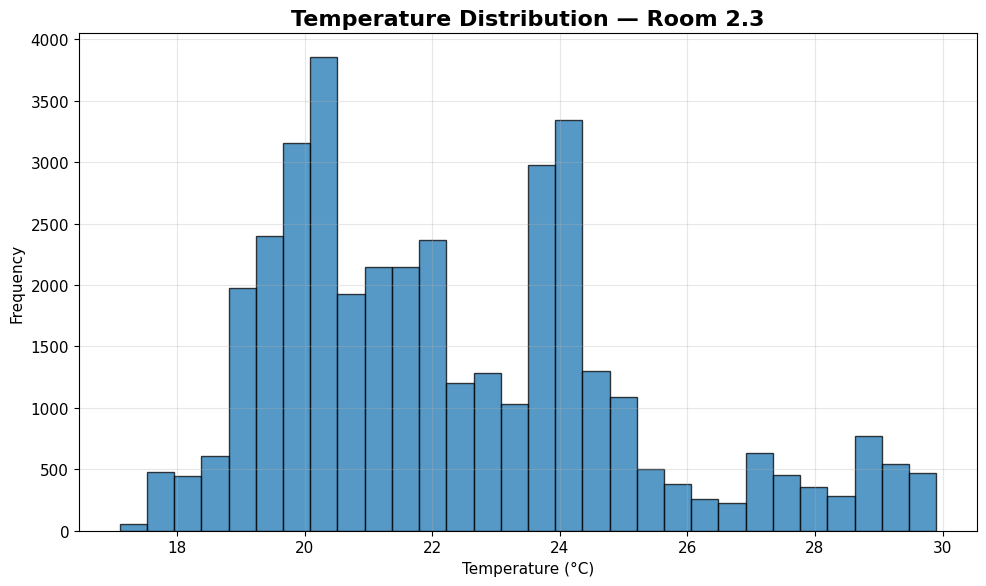

Saved: Figure_2_7_Temperature_Distribution_Room_2_3.png


In [12]:
# FIGURE 2.7 — TEMPERATURE DISTRIBUTION


fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    df["temperature"],
    bins=30,
    edgecolor="black",
    alpha=0.75
)

ax.set_title(
    "Temperature Distribution — Room 2.3",
    fontsize=16,
    weight="bold"
)

ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Frequency")

ax.grid(alpha=0.3)

plt.tight_layout()

file_name = "Figure_2_7_Temperature_Distribution_Room_2_3.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

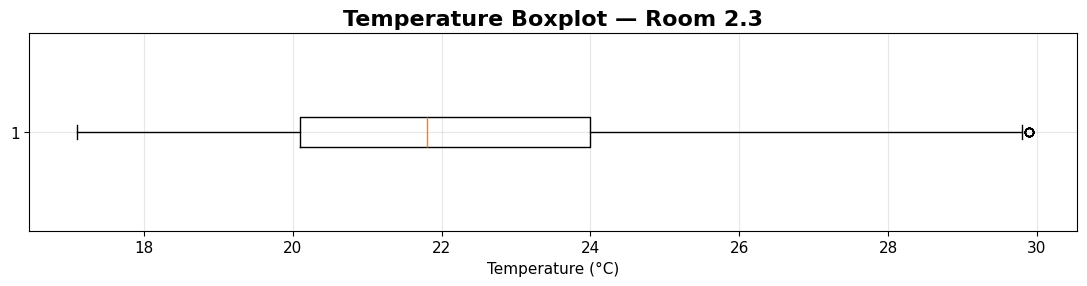

Saved: Figure_2_8_Temperature_Boxplot_Room_2_3.png


In [13]:
# FIGURE 2.8 — TEMPERATURE BOXPLOT


fig, ax = plt.subplots(figsize=(11, 3))

ax.boxplot(
    df["temperature"],
    vert=False
)

ax.set_title(
    "Temperature Boxplot — Room 2.3",
    fontsize=16,
    weight="bold"
)

ax.set_xlabel("Temperature (°C)")
ax.grid(alpha=0.3)

plt.tight_layout()

file_name = "Figure_2_8_Temperature_Boxplot_Room_2_3.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

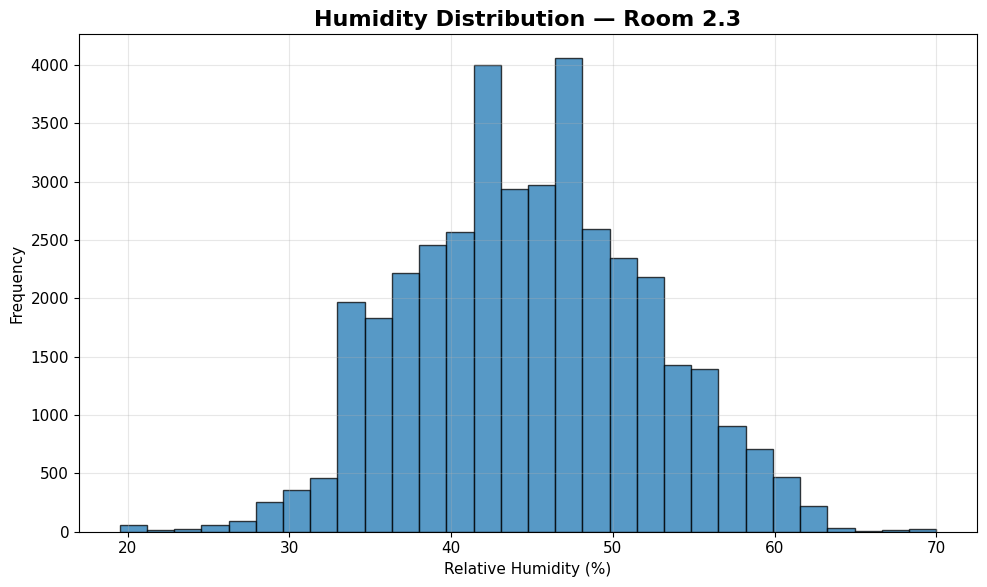

Saved: Figure_2_9_Humidity_Distribution_Room_2_3.png


In [14]:
# FIGURE 2.9 — HUMIDITY DISTRIBUTION


fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    df["humidity"],
    bins=30,
    edgecolor="black",
    alpha=0.75
)

ax.set_title(
    "Humidity Distribution — Room 2.3",
    fontsize=16,
    weight="bold"
)

ax.set_xlabel("Relative Humidity (%)")
ax.set_ylabel("Frequency")

ax.grid(alpha=0.3)

plt.tight_layout()

file_name = "Figure_2_9_Humidity_Distribution_Room_2_3.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

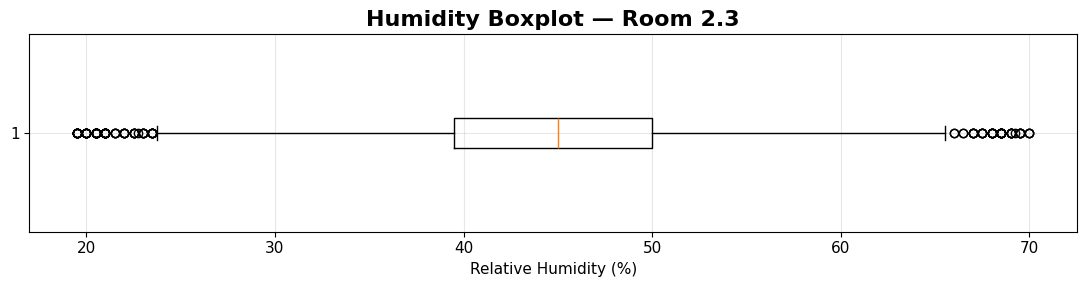

Saved: Figure_2_10_Humidity_Boxplot_Room_2_3.png


In [15]:
# FIGURE 2.10 — HUMIDITY BOXPLOT


fig, ax = plt.subplots(figsize=(11, 3))

ax.boxplot(
    df["humidity"],
    vert=False
)

ax.set_title(
    "Humidity Boxplot — Room 2.3",
    fontsize=16,
    weight="bold"
)

ax.set_xlabel("Relative Humidity (%)")
ax.grid(alpha=0.3)

plt.tight_layout()

file_name = "Figure_2_10_Humidity_Boxplot_Room_2_3.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

## 6. Occupancy Analysis

This section examines the occupancy patterns of Room 2.3 based on the `people_count_all` variable, including its distribution and temporal characteristics.

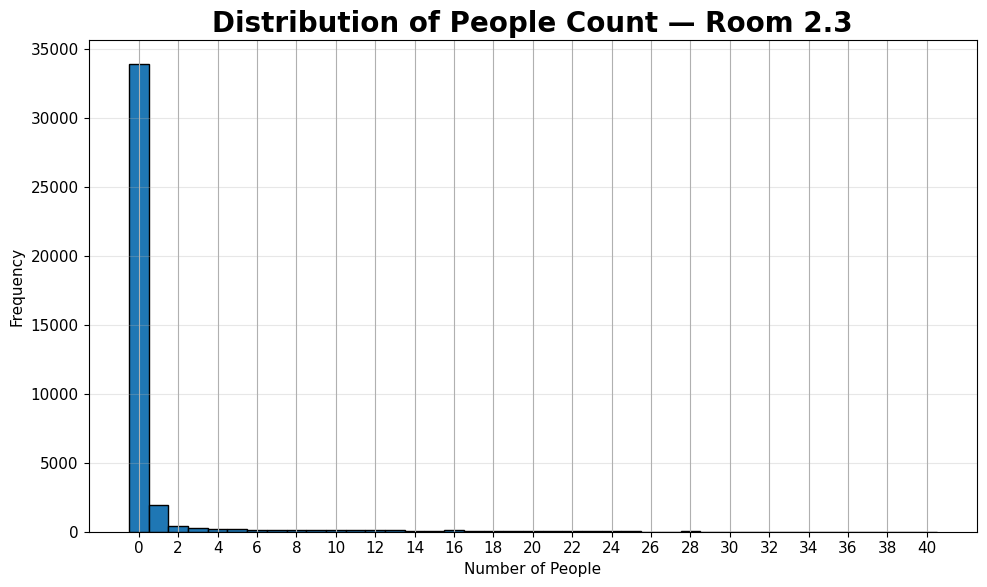

Saved: Figure_2_11_People_Count_Distribution_Room_2_3.png


In [16]:
# FIGURE 2.11 — PEOPLE COUNT DISTRIBUTION


fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    df["people_count_all"],
    bins=np.arange(-0.5, df["people_count_all"].max() + 1.5, 1),
    edgecolor="black"
)

ax.set_title(
    "Distribution of People Count — Room 2.3",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("Number of People")
ax.set_ylabel("Frequency")

ax.set_xticks(
    range(0, int(df["people_count_all"].max()) + 1, 2)
)

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

file_name = "Figure_2_11_People_Count_Distribution_Room_2_3.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

In [17]:
# PEOPLE COUNT — DESCRIPTIVE STATISTICS


people_stats = df["people_count_all"].describe()

print(people_stats)

print(f"\nMedian:   {df['people_count_all'].median():.3f}")
print(f"Variance: {df['people_count_all'].var():.3f}")
print(f"Skewness: {df['people_count_all'].skew():.3f}")

count    38645.000000
mean         0.762453
std          3.236748
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         40.000000
Name: people_count_all, dtype: float64

Median:   0.000
Variance: 10.477
Skewness: 5.860


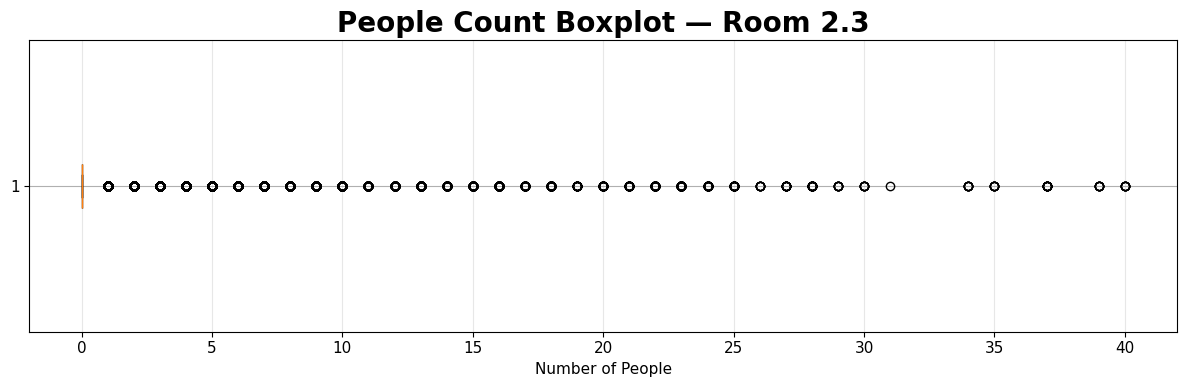

Saved: Figure_2_12_People_Count_Boxplot_Room_2_3.png


In [18]:
# FIGURE 2.12 — PEOPLE COUNT BOXPLOT


fig, ax = plt.subplots(figsize=(12, 4))

ax.boxplot(
    df["people_count_all"],
    vert=False,
    patch_artist=True
)

ax.set_title(
    "People Count Boxplot — Room 2.3",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("Number of People")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()

file_name = "Figure_2_12_People_Count_Boxplot_Room_2_3.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

In [19]:
# PEOPLE COUNT — IQR OUTLIER ANALYSIS


Q1 = df["people_count_all"].quantile(0.25)
Q2 = df["people_count_all"].median()
Q3 = df["people_count_all"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["people_count_all"] < lower_bound) |
    (df["people_count_all"] > upper_bound)
]

outlier_percentage = len(outliers) / len(df) * 100

print(f"Q1:     {Q1}")
print(f"Median: {Q2}")
print(f"Q3:     {Q3}")
print(f"IQR:    {IQR}")

print(f"\nLower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")

print(f"\nNumber of outliers: {len(outliers)}")
print(f"Percentage: {outlier_percentage:.2f}%")

Q1:     0.0
Median: 0.0
Q3:     0.0
IQR:    0.0

Lower bound: 0.0
Upper bound: 0.0

Number of outliers: 4745
Percentage: 12.28%


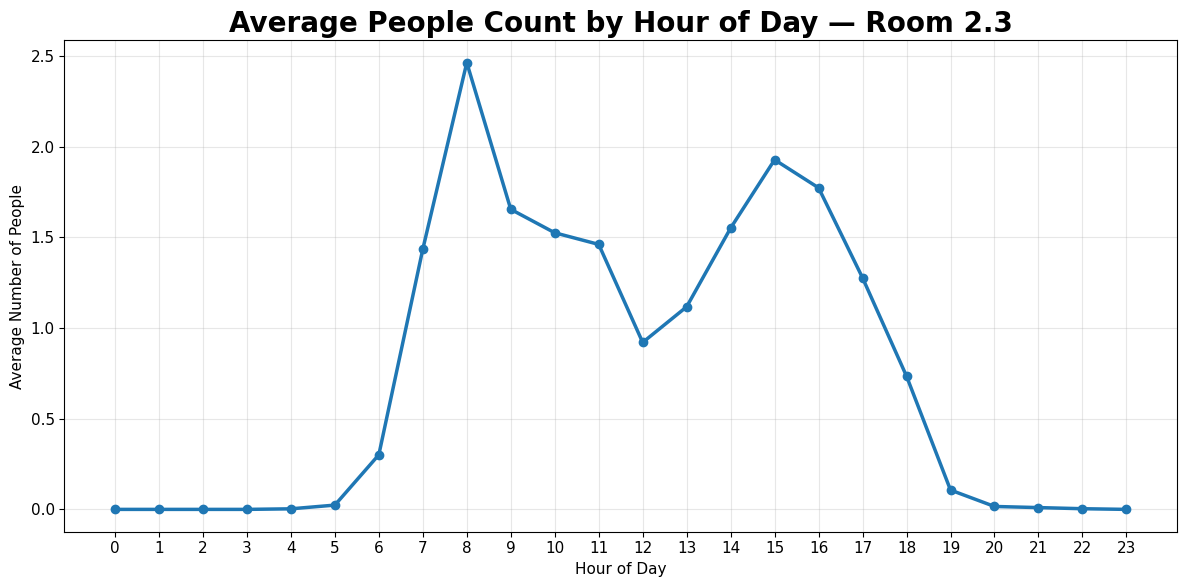

Saved: Figure_2_13_Average_People_Count_by_Hour_Room_2_3.png


In [20]:
# FIGURE 2.13 — AVERAGE PEOPLE COUNT BY HOUR OF DAY


# Extract hour from timestamp
df["hour"] = df["ts"].dt.hour

# Calculate average people count per hour
hourly_people = df.groupby("hour")["people_count_all"].mean()

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    hourly_people.index,
    hourly_people.values,
    marker="o",
    linewidth=2.5
)

ax.set_title(
    "Average People Count by Hour of Day — Room 2.3",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Average Number of People")

ax.set_xticks(range(24))
ax.grid(alpha=0.3)

plt.tight_layout()

file_name = "Figure_2_13_Average_People_Count_by_Hour_Room_2_3.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

In [21]:
# Display hourly occupancy averages
hourly_people_df = (
    hourly_people
    .round(2)
    .reset_index()
)

hourly_people_df.columns = [
    "Hour",
    "Average People Count"
]

display(hourly_people_df)

,Hour,Average People Count
0,0,0.00
1,1,0.00
2,2,0.00
3,3,0.00
4,4,0.00
5,5,0.02
6,6,0.30
7,7,1.43
8,8,2.46
9,9,1.65


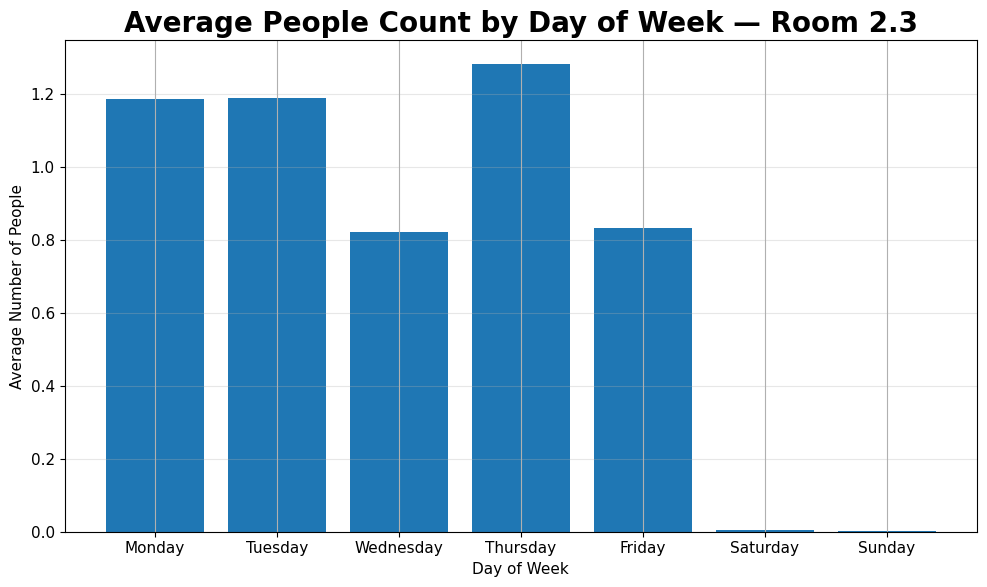

Saved: Figure_2_14_Average_People_Count_by_Weekday_Room_2_3.png


In [22]:
# FIGURE 2.14 — AVERAGE PEOPLE COUNT BY DAY OF WEEK


# Extract weekday from timestamp
df["weekday"] = df["ts"].dt.day_name()

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# Calculate average people count per weekday
weekday_people = (
    df.groupby("weekday")["people_count_all"]
    .mean()
    .reindex(weekday_order)
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    weekday_people.index,
    weekday_people.values
)

ax.set_title(
    "Average People Count by Day of Week — Room 2.3",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("Day of Week")
ax.set_ylabel("Average Number of People")

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

file_name = "Figure_2_14_Average_People_Count_by_Weekday_Room_2_3.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

In [23]:
# Display weekday occupancy averages
weekday_people_df = (
    weekday_people
    .round(2)
    .reset_index()
)

weekday_people_df.columns = [
    "Weekday",
    "Average People Count"
]

display(weekday_people_df)

,Weekday,Average People Count
0,Monday,1.19
1,Tuesday,1.19
2,Wednesday,0.82
3,Thursday,1.28
4,Friday,0.83
5,Saturday,0.00
6,Sunday,0.00


## 7. Additional Sensor Variables

This section examines the light level and PIR measurements recorded in Room 2.3.

In [24]:
# LIGHT LEVEL — DESCRIPTIVE STATISTICS


print(df["light_level"].describe())

print(f"\nMedian:   {df['light_level'].median():.3f}")
print(f"Variance: {df['light_level'].var():.3f}")
print(f"Skewness: {df['light_level'].skew():.3f}")

count    38645.00000
mean         0.72096
std          0.91836
min          0.00000
25%          0.00000
50%          0.00000
75%          1.00000
max          3.00000
Name: light_level, dtype: float64

Median:   0.000
Variance: 0.843
Skewness: 0.989


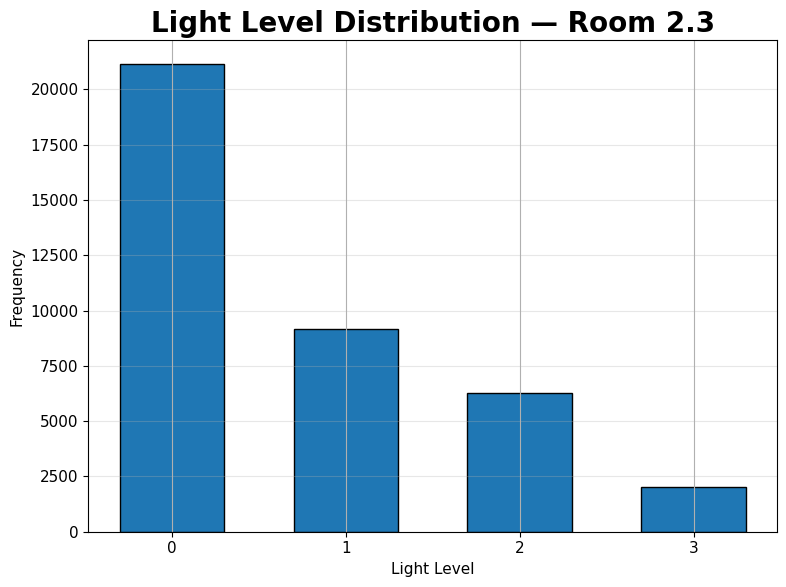

Saved: Figure_2_15_Light_Level_Distribution_Room_2_3.png


In [25]:
# FIGURE 2.15 — LIGHT LEVEL DISTRIBUTION


counts = (
    df["light_level"]
    .astype(int)
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.bar(
    counts.index,
    counts.values,
    width=0.6,
    edgecolor="black"
)

ax.set_title(
    "Light Level Distribution — Room 2.3",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("Light Level")
ax.set_ylabel("Frequency")

# Display only the observed light-level scale
ax.set_xticks([0, 1, 2, 3])

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

file_name = "Figure_2_15_Light_Level_Distribution_Room_2_3.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

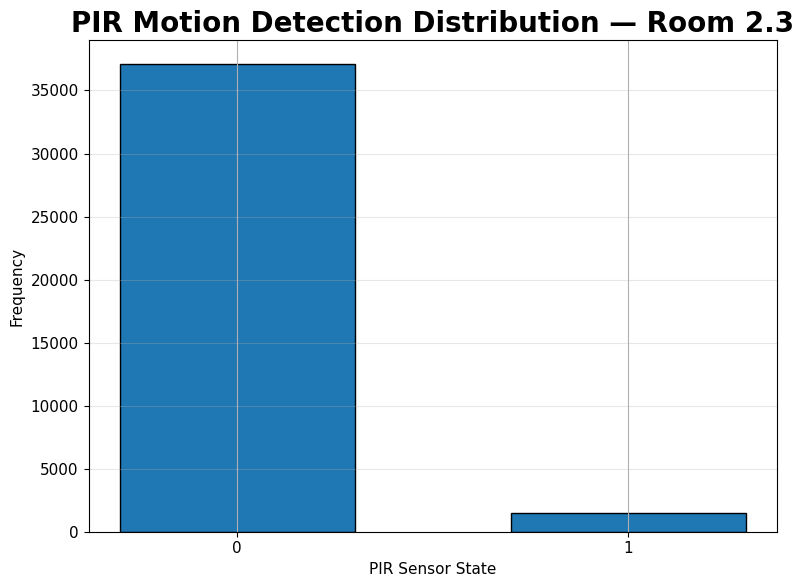

Saved: Figure_2_16_PIR_Distribution_Room_2_3.png


In [26]:
# FIGURE 2.16 — PIR MOTION DETECTION DISTRIBUTION


pir_counts = (
    df["pir"]
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.bar(
    pir_counts.index.astype(str),
    pir_counts.values,
    edgecolor="black",
    width=0.6
)

ax.set_title(
    "PIR Motion Detection Distribution — Room 2.3",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("PIR Sensor State")
ax.set_ylabel("Frequency")

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

file_name = "Figure_2_16_PIR_Distribution_Room_2_3.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

In [27]:
# PIR — DESCRIPTIVE STATISTICS


print(df["pir"].describe())

pir_counts = (
    df["pir"]
    .value_counts()
    .sort_index()
)

pir_summary = pir_counts.to_frame(name="Count")

pir_summary["Percentage (%)"] = (
    pir_summary["Count"] / len(df) * 100
).round(2)

display(pir_summary)

count    38645.000000
mean         0.039410
std          0.194571
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: pir, dtype: float64


,Count,Percentage (%)
pir,,
0,37122,96.06
1,1523,3.94


## 8. Relationships and Correlations

This section examines the relationships among environmental, occupancy, and sensor variables in Room 2.3 using correlation analysis and pairwise visualizations.

Variables excluded due to zero variance:
['region_count']


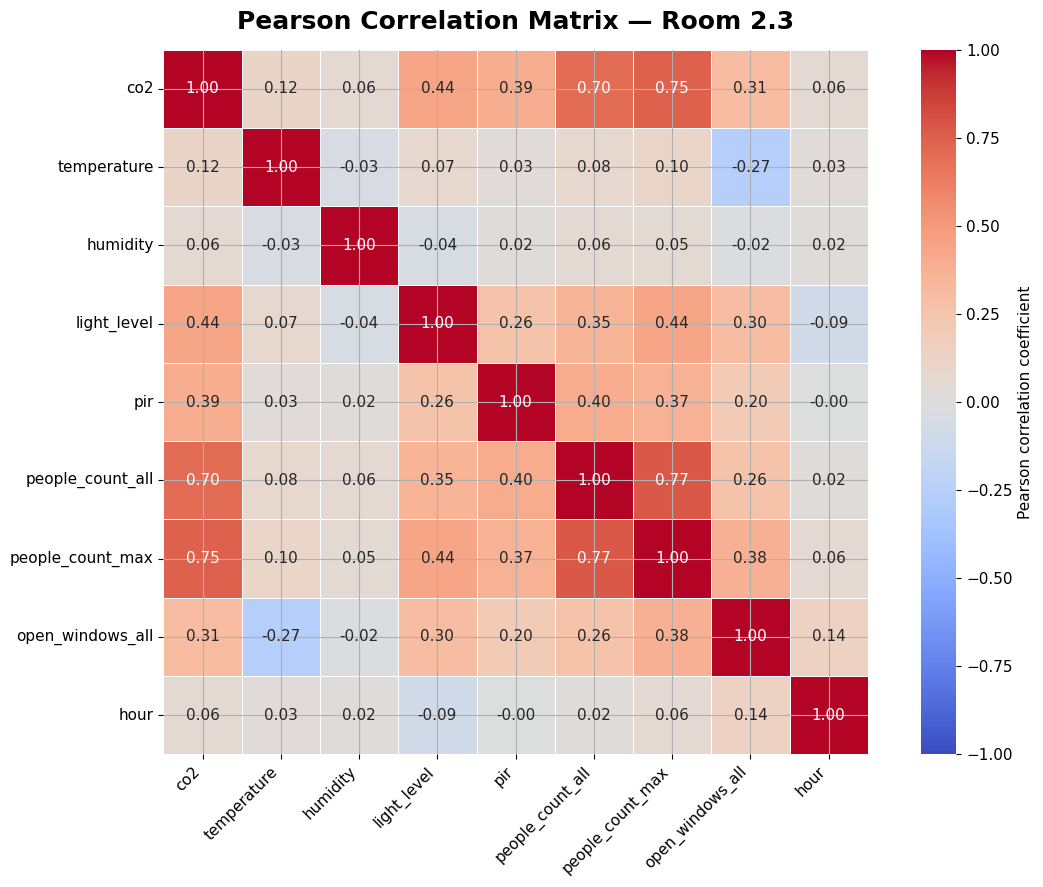

Saved: Figure_2_17_Correlation_Matrix_Room_2_3.png


In [28]:
# FIGURE 2.17 — CORRELATION MATRIX


# Select numerical variables
numeric_df = df.select_dtypes(include=["number"]).copy()

# Identify and remove zero-variance variables
zero_variance_columns = [
    col
    for col in numeric_df.columns
    if numeric_df[col].nunique() <= 1
]

numeric_df = numeric_df.drop(
    columns=zero_variance_columns
)

print("Variables excluded due to zero variance:")
print(zero_variance_columns)

# Calculate Pearson correlation matrix
corr = numeric_df.corr(method="pearson")

fig, ax = plt.subplots(figsize=(12, 9))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    fmt=".2f",
    cbar_kws={
        "label": "Pearson correlation coefficient"
    },
    ax=ax
)

ax.set_title(
    "Pearson Correlation Matrix — Room 2.3",
    fontsize=18,
    weight="bold",
    pad=15
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(rotation=0)

plt.tight_layout()

file_name = "Figure_2_17_Correlation_Matrix_Room_2_3.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

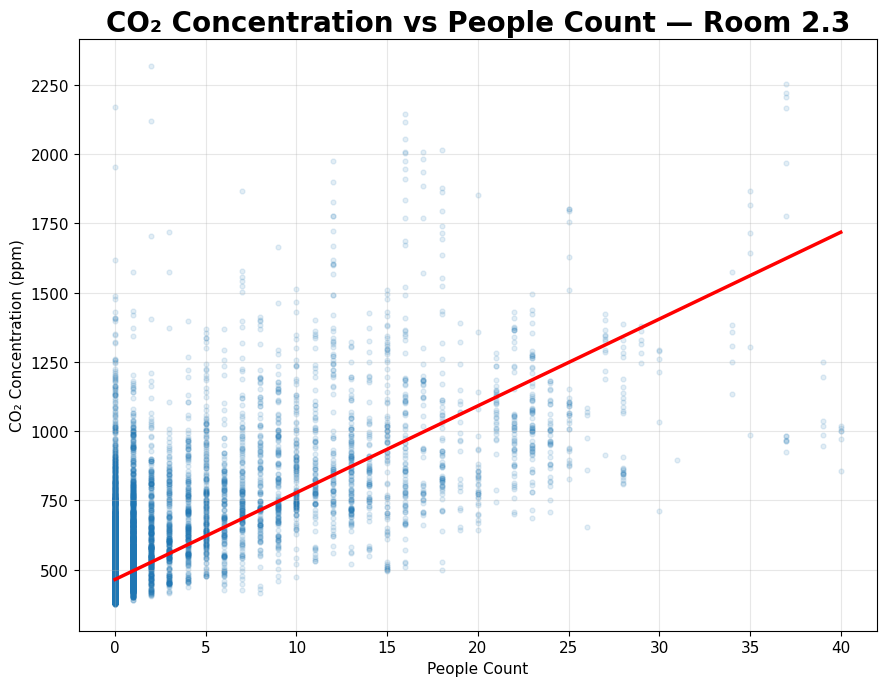

Saved: Figure_2_18_CO2_vs_People_Count_Room_2_3.png


In [29]:
# FIGURE 2.18 — CO₂ VS PEOPLE COUNT


fig, ax = plt.subplots(figsize=(9, 7))

sns.regplot(
    data=df,
    x="people_count_all",
    y="co2",
    scatter_kws={
        "alpha": 0.12,
        "s": 12
    },
    line_kws={
        "color": "red",
        "linewidth": 2.5
    },
    ci=None,
    ax=ax
)

ax.set_title(
    "CO₂ Concentration vs People Count — Room 2.3",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("People Count")
ax.set_ylabel("CO₂ Concentration (ppm)")

ax.grid(alpha=0.3)

plt.tight_layout()

file_name = "Figure_2_18_CO2_vs_People_Count_Room_2_3.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

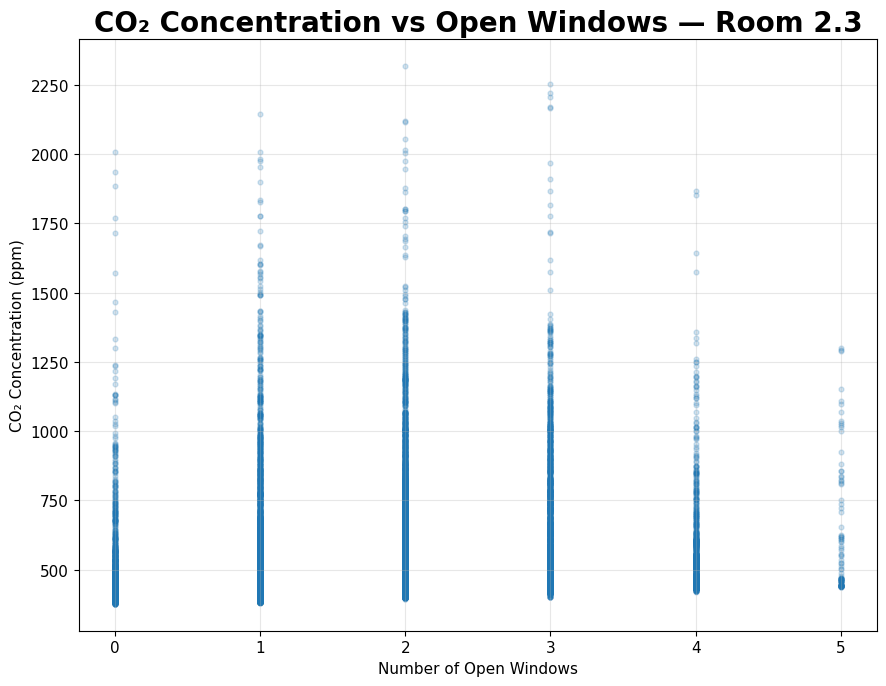

Saved: Figure_2_19_CO2_vs_Open_Windows_Room_2_3.png


In [30]:
# FIGURE 2.19 — CO₂ VS OPEN WINDOWS


fig, ax = plt.subplots(figsize=(9, 7))

ax.scatter(
    df["open_windows_all"],
    df["co2"],
    alpha=0.20,
    s=12
)

ax.set_title(
    "CO₂ Concentration vs Open Windows — Room 2.3",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("Number of Open Windows")
ax.set_ylabel("CO₂ Concentration (ppm)")

ax.set_xticks(
    range(
        int(df["open_windows_all"].min()),
        int(df["open_windows_all"].max()) + 1
    )
)

ax.grid(alpha=0.3)

plt.tight_layout()

file_name = "Figure_2_19_CO2_vs_Open_Windows_Room_2_3.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

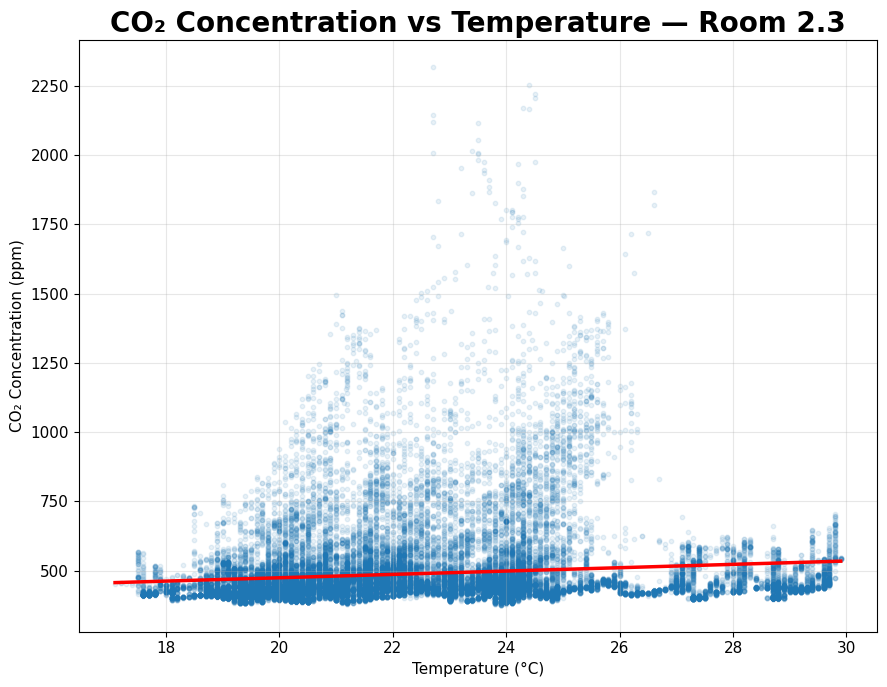

Saved: Figure_2_20_CO2_vs_Temperature_Room_2_3.png


In [31]:
# FIGURE 2.20 — CO₂ VS TEMPERATURE


fig, ax = plt.subplots(figsize=(9, 7))

sns.regplot(
    data=df,
    x="temperature",
    y="co2",
    scatter_kws={
        "alpha": 0.10,
        "s": 10
    },
    line_kws={
        "color": "red",
        "linewidth": 2.5
    },
    ci=None,
    ax=ax
)

ax.set_title(
    "CO₂ Concentration vs Temperature — Room 2.3",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("CO₂ Concentration (ppm)")
ax.grid(alpha=0.3)

plt.tight_layout()

file_name = "Figure_2_20_CO2_vs_Temperature_Room_2_3.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

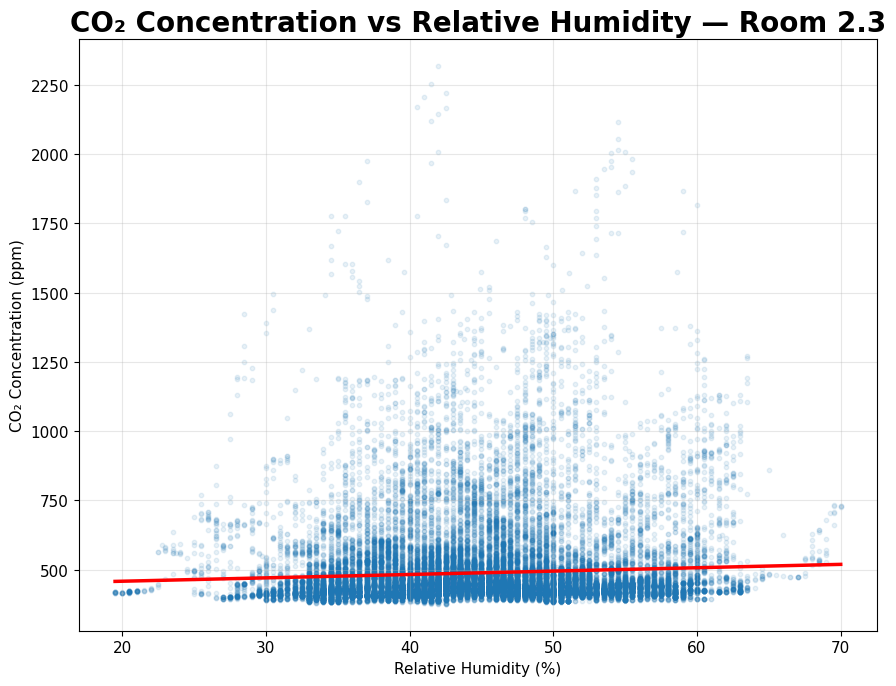

Saved: Figure_2_21_CO2_vs_Humidity_Room_2_3.png


In [32]:
# FIGURE 2.21 — CO₂ VS HUMIDITY


fig, ax = plt.subplots(figsize=(9, 7))

sns.regplot(
    data=df,
    x="humidity",
    y="co2",
    scatter_kws={
        "alpha": 0.10,
        "s": 10
    },
    line_kws={
        "color": "red",
        "linewidth": 2.5
    },
    ci=None,
    ax=ax
)

ax.set_title(
    "CO₂ Concentration vs Relative Humidity — Room 2.3",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("Relative Humidity (%)")
ax.set_ylabel("CO₂ Concentration (ppm)")
ax.grid(alpha=0.3)

plt.tight_layout()

file_name = "Figure_2_21_CO2_vs_Humidity_Room_2_3.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

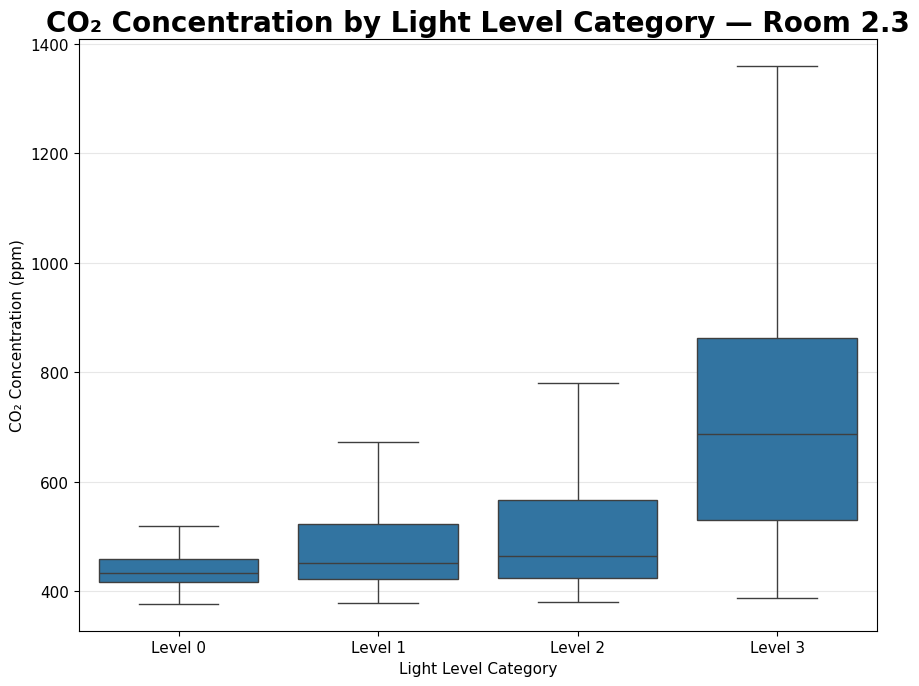

Saved: Figure_2_22_CO2_by_Light_Level_Category_Room_2_3.png


In [33]:
# FIGURE 2.22 — CO₂ BY LIGHT LEVEL CATEGORY


# Create light-level categories
df["light_category"] = pd.cut(
    df["light_level"],
    bins=[-0.01, 0.49, 1.49, 2.49, 3.01],
    labels=[
        "Level 0",
        "Level 1",
        "Level 2",
        "Level 3"
    ]
)

fig, ax = plt.subplots(figsize=(9, 7))

sns.boxplot(
    data=df,
    x="light_category",
    y="co2",
    showfliers=False,
    order=[
        "Level 0",
        "Level 1",
        "Level 2",
        "Level 3"
    ],
    ax=ax
)

ax.set_title(
    "CO₂ Concentration by Light Level Category — Room 2.3",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("Light Level Category")
ax.set_ylabel("CO₂ Concentration (ppm)")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

file_name = "Figure_2_22_CO2_by_Light_Level_Category_Room_2_3.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

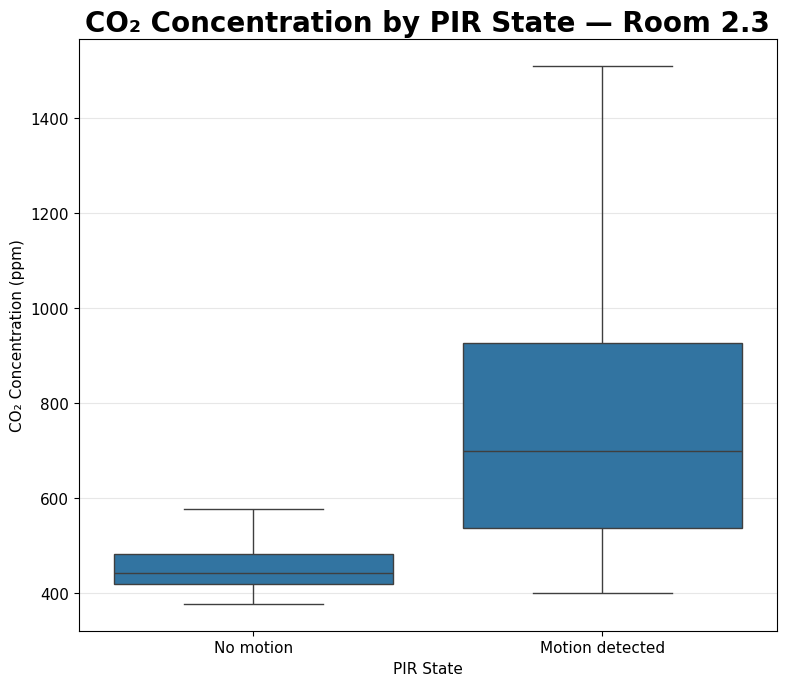

Saved: Figure_2_23_CO2_by_PIR_State_Room_2_3.png


In [34]:
# FIGURE 2.23 — CO₂ BY PIR STATE


pir_labels = {
    0: "No motion",
    1: "Motion detected"
}

df["pir_label"] = df["pir"].map(pir_labels)

fig, ax = plt.subplots(figsize=(8, 7))

sns.boxplot(
    data=df,
    x="pir_label",
    y="co2",
    showfliers=False,
    order=[
        "No motion",
        "Motion detected"
    ],
    ax=ax
)

ax.set_title(
    "CO₂ Concentration by PIR State — Room 2.3",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("PIR State")
ax.set_ylabel("CO₂ Concentration (ppm)")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

file_name = "Figure_2_23_CO2_by_PIR_State_Room_2_3.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

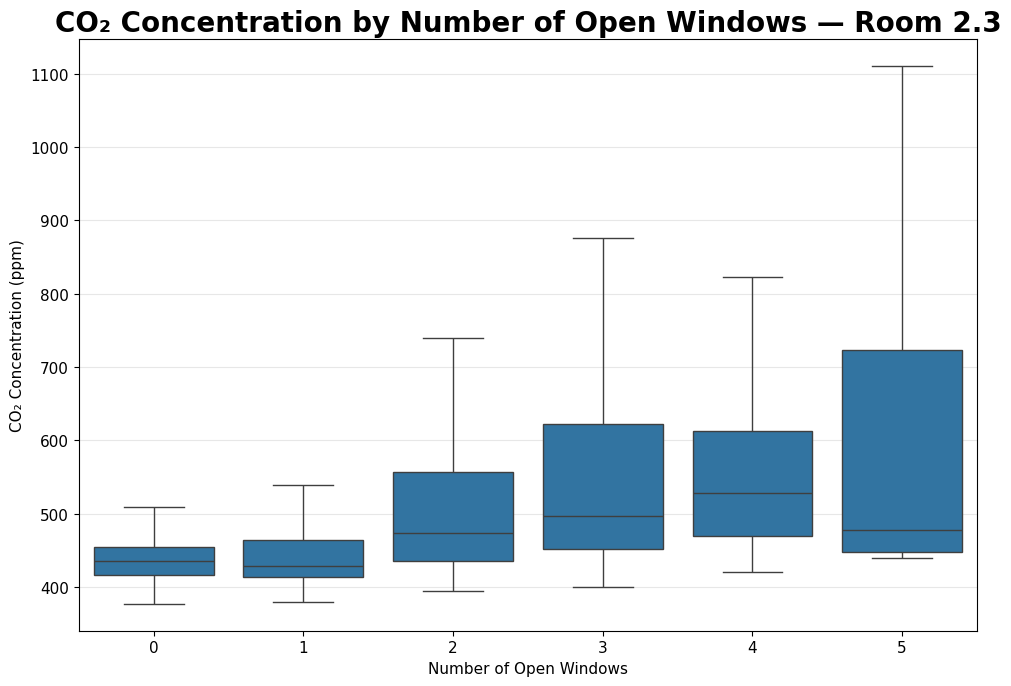

Saved: Figure_2_24_CO2_by_Open_Windows_Room_2_3.png


In [35]:
# FIGURE 2.24 — CO₂ BY NUMBER OF OPEN WINDOWS


fig, ax = plt.subplots(figsize=(10, 7))

sns.boxplot(
    data=df,
    x="open_windows_all",
    y="co2",
    showfliers=False,
    ax=ax
)

ax.set_title(
    "CO₂ Concentration by Number of Open Windows — Room 2.3",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("Number of Open Windows")
ax.set_ylabel("CO₂ Concentration (ppm)")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

file_name = "Figure_2_24_CO2_by_Open_Windows_Room_2_3.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

Occupied observations: 4745
Percentage of total observations: 12.28 %


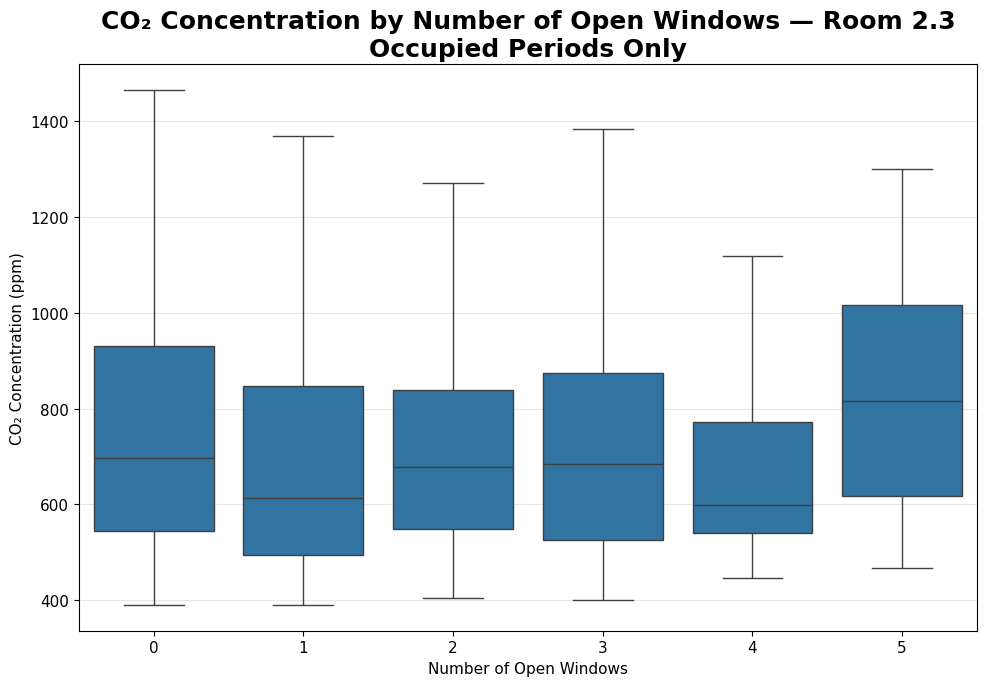

Saved: Figure_CO2_by_Open_Windows_Room_2_3_Occupied_Only.png


In [36]:
# ADDITIONAL ANALYSIS — CO₂ BY OPEN WINDOWS DURING OCCUPANCY


# Keep only observations with recorded occupancy
df_occupied = df[
    df["people_count_all"] > 0
].copy()

print("Occupied observations:", len(df_occupied))
print(
    "Percentage of total observations:",
    round(100 * len(df_occupied) / len(df), 2),
    "%"
)

fig, ax = plt.subplots(figsize=(10, 7))

sns.boxplot(
    data=df_occupied,
    x="open_windows_all",
    y="co2",
    showfliers=False,
    ax=ax
)

ax.set_title(
    "CO₂ Concentration by Number of Open Windows — Room 2.3\n"
    "Occupied Periods Only",
    fontsize=18,
    weight="bold"
)

ax.set_xlabel("Number of Open Windows")
ax.set_ylabel("CO₂ Concentration (ppm)")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

file_name = "Figure_CO2_by_Open_Windows_Room_2_3_Occupied_Only.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

In [37]:
# Summarize CO₂ and occupancy by number of open windows
# during occupied periods
occupied_window_summary = (
    df_occupied
    .groupby("open_windows_all")
    .agg(
        observations=("co2", "size"),
        mean_co2=("co2", "mean"),
        median_co2=("co2", "median"),
        mean_occupancy=("people_count_all", "mean")
    )
    .round(2)
)

display(occupied_window_summary)

,observations,mean_co2,median_co2,mean_occupancy
open_windows_all,,,,
0,138,773.29,698.0,4.82
1,1122,709.78,613.0,4.29
2,1907,734.14,679.0,5.79
3,1191,730.83,685.0,8.45
4,349,680.58,599.0,6.62
5,38,820.87,817.0,15.37


## 9. Temporal Patterns

This section examines temporal patterns in indoor air quality and occupancy across different hours, weekdays, and months.

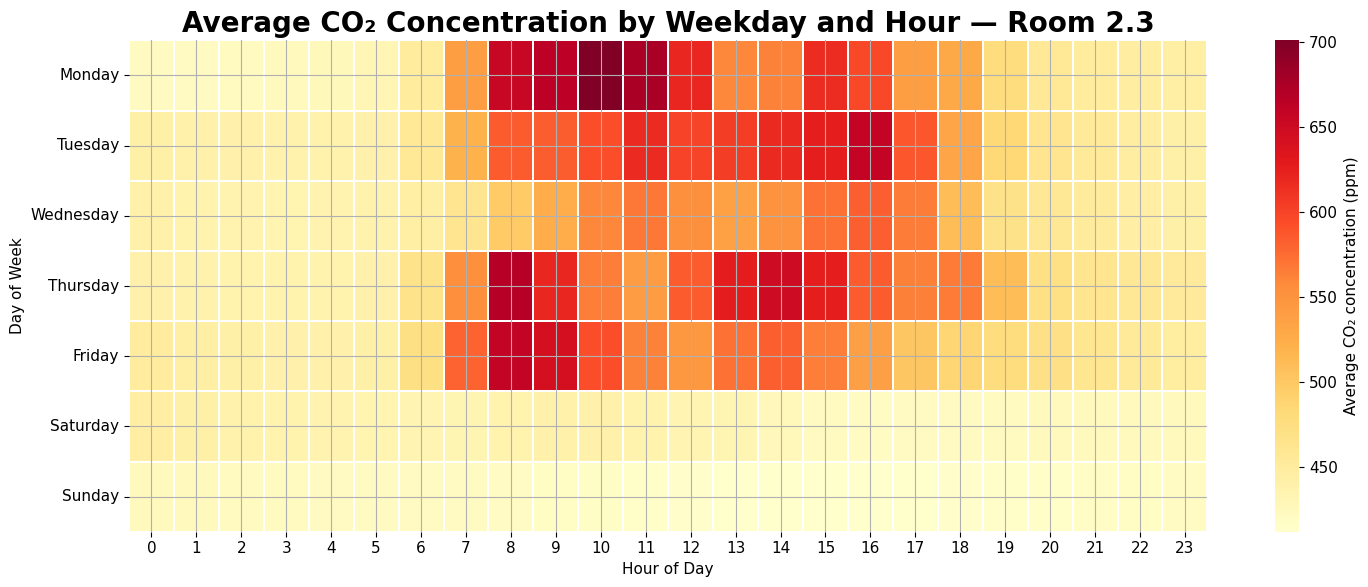

Saved: Figure_2_25_CO2_Weekday_Hour_Heatmap_Room_2_3.png


In [38]:
# FIGURE 2.25 — CO₂ HEATMAP BY WEEKDAY AND HOUR


weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# Extract temporal features
df["hour"] = df["ts"].dt.hour
df["weekday"] = df["ts"].dt.day_name()

# Calculate average CO₂ concentration by weekday and hour
co2_heatmap = (
    df.pivot_table(
        index="weekday",
        columns="hour",
        values="co2",
        aggfunc="mean"
    )
    .reindex(weekday_order)
)

fig, ax = plt.subplots(figsize=(15, 6))

sns.heatmap(
    co2_heatmap,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.3,
    cbar_kws={
        "label": "Average CO₂ concentration (ppm)"
    },
    ax=ax
)

ax.set_title(
    "Average CO₂ Concentration by Weekday and Hour — Room 2.3",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Day of Week")

plt.tight_layout()

file_name = "Figure_2_25_CO2_Weekday_Hour_Heatmap_Room_2_3.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

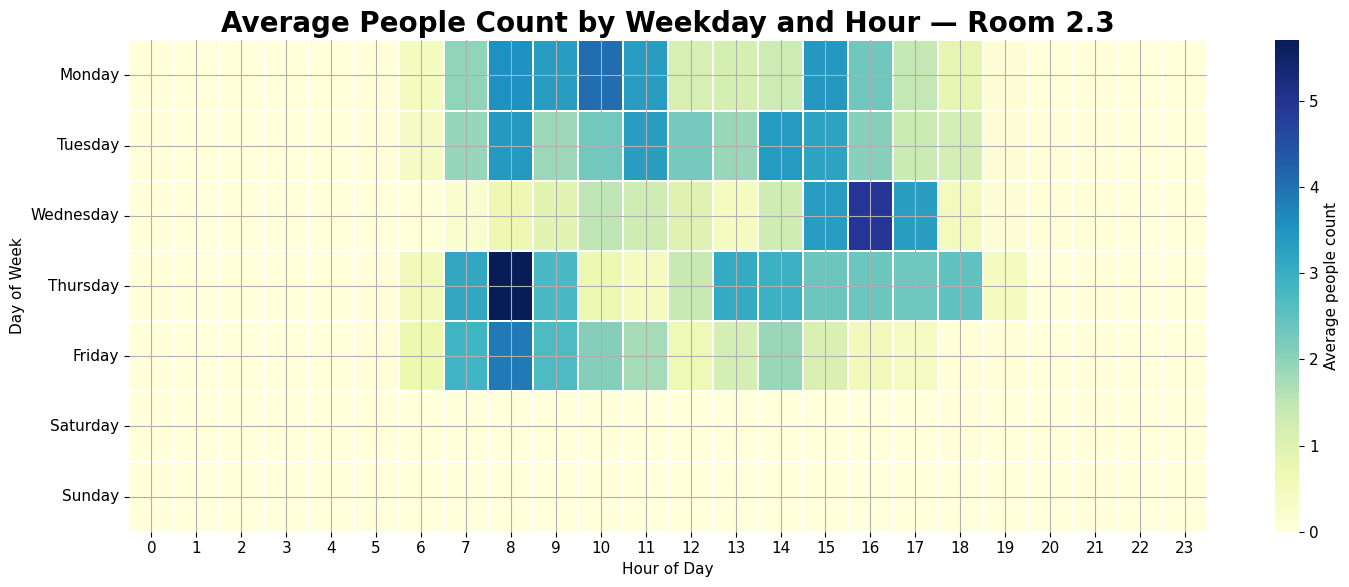

Saved: Figure_2_26_Occupancy_Weekday_Hour_Heatmap_Room_2_3.png


In [39]:
# FIGURE 2.26 — OCCUPANCY HEATMAP BY WEEKDAY AND HOUR


# Calculate average people count by weekday and hour
people_heatmap = (
    df.pivot_table(
        index="weekday",
        columns="hour",
        values="people_count_all",
        aggfunc="mean"
    )
    .reindex(weekday_order)
)

fig, ax = plt.subplots(figsize=(15, 6))

sns.heatmap(
    people_heatmap,
    cmap="YlGnBu",
    annot=False,
    linewidths=0.3,
    cbar_kws={
        "label": "Average people count"
    },
    ax=ax
)

ax.set_title(
    "Average People Count by Weekday and Hour — Room 2.3",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Day of Week")

plt.tight_layout()

file_name = "Figure_2_26_Occupancy_Weekday_Hour_Heatmap_Room_2_3.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

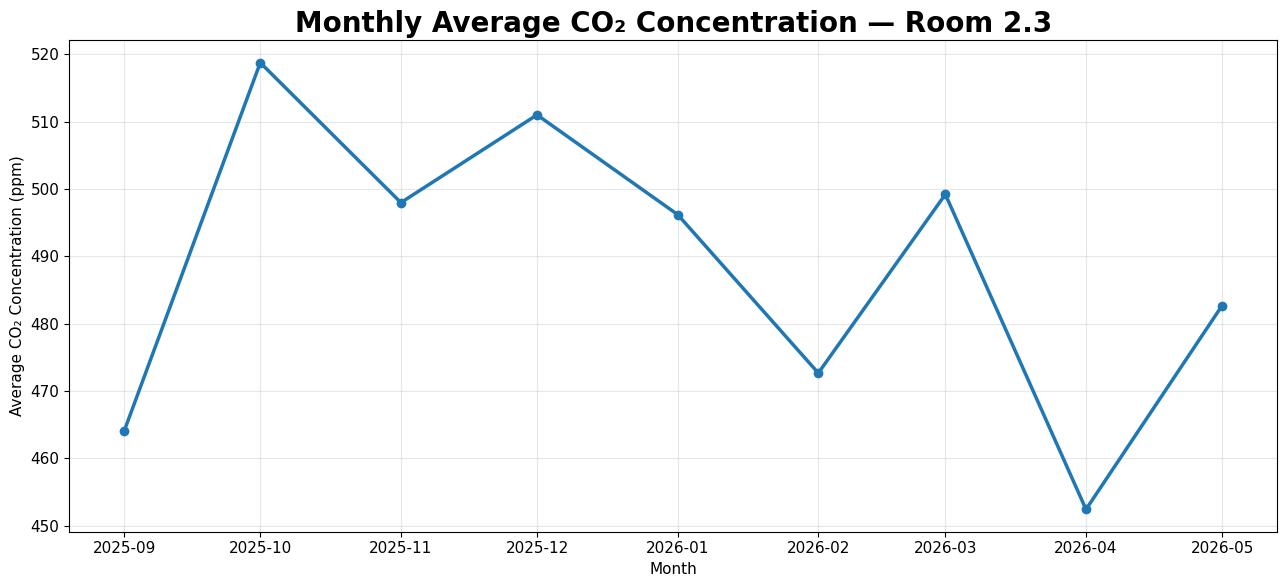

Saved: Figure_2_27_Monthly_Average_CO2_Room_2_3.png


In [40]:
# FIGURE 2.27 — MONTHLY AVERAGE CO₂

# Calculate monthly average CO₂ concentration
monthly_co2 = (
    df.set_index("ts")["co2"]
    .resample("MS")
    .mean()
)

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    monthly_co2.index,
    monthly_co2.values,
    marker="o",
    linewidth=2.5
)

ax.set_title(
    "Monthly Average CO₂ Concentration — Room 2.3",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("Month")
ax.set_ylabel("Average CO₂ Concentration (ppm)")
ax.grid(alpha=0.3)

plt.tight_layout()

file_name = "Figure_2_27_Monthly_Average_CO2_Room_2_3.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

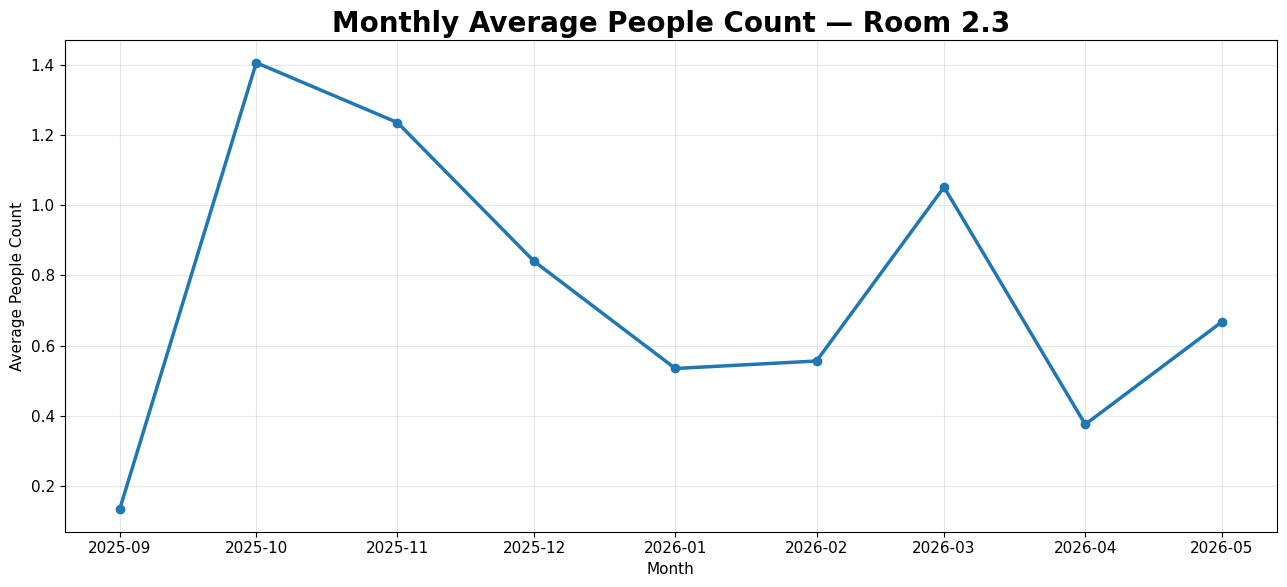

Saved: Figure_2_28_Monthly_Average_People_Count_Room_2_3.png


In [41]:
# FIGURE 2.28 — MONTHLY AVERAGE PEOPLE COUNT


# Calculate monthly average people count
monthly_people = (
    df.set_index("ts")["people_count_all"]
    .resample("MS")
    .mean()
)

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    monthly_people.index,
    monthly_people.values,
    marker="o",
    linewidth=2.5
)

ax.set_title(
    "Monthly Average People Count — Room 2.3",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("Month")
ax.set_ylabel("Average People Count")
ax.grid(alpha=0.3)

plt.tight_layout()

file_name = "Figure_2_28_Monthly_Average_People_Count_Room_2_3.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {file_name}")

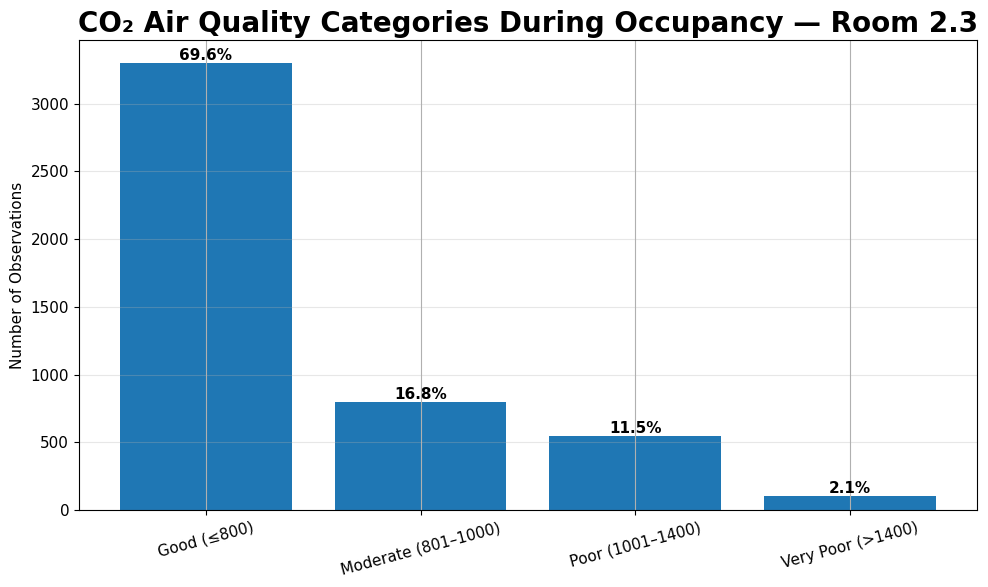

,Count,Percentage (%)
co2_category,,
Good (≤800),3303,69.61
Moderate (801–1000),796,16.78
Poor (1001–1400),544,11.46
Very Poor (>1400),102,2.15


Occupied observations: 4745
Saved: Figure_2_29_CO2_Categories_During_Occupancy_Room_2_3.png


In [42]:
# FIGURE 2.29 — CO₂ CATEGORIES DURING OCCUPANCY


# Keep only observations with recorded occupancy
occupied_df = df[
    df["people_count_all"] > 0
].copy()

# Classify CO₂ observations into air quality categories
occupied_df["co2_category"] = pd.cut(
    occupied_df["co2"],
    bins=[0, 800, 1000, 1400, np.inf],
    labels=[
        "Good (≤800)",
        "Moderate (801–1000)",
        "Poor (1001–1400)",
        "Very Poor (>1400)"
    ]
)

occupied_category_counts = (
    occupied_df["co2_category"]
    .value_counts()
    .sort_index()
)

occupied_category_percent = (
    occupied_category_counts /
    occupied_category_counts.sum() * 100
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    occupied_category_counts.index.astype(str),
    occupied_category_counts.values
)

# Add percentage labels above each bar
for bar, percentage in zip(
    bars,
    occupied_category_percent
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentage:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.set_title(
    "CO₂ Air Quality Categories During Occupancy — Room 2.3",
    fontsize=20,
    weight="bold"
)

ax.set_xlabel("")
ax.set_ylabel("Number of Observations")
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=15)
plt.tight_layout()

file_name = "Figure_2_29_CO2_Categories_During_Occupancy_Room_2_3.png"

plt.savefig(
    file_name,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

occupied_category_summary = pd.DataFrame({
    "Count": occupied_category_counts,
    "Percentage (%)": occupied_category_percent.round(2)
})

display(occupied_category_summary)

print(f"Occupied observations: {len(occupied_df)}")
print(f"Saved: {file_name}")

In [43]:
# CORRELATIONS WITH CO₂


analysis_columns = [
    "co2",
    "temperature",
    "humidity",
    "light_level",
    "pir",
    "people_count_all",
    "people_count_max",
    "open_windows_all"
]

pearson_with_co2 = (
    df[analysis_columns]
    .corr(method="pearson")["co2"]
    .drop("co2")
)

spearman_with_co2 = (
    df[analysis_columns]
    .corr(method="spearman")["co2"]
    .drop("co2")
)

correlation_summary = pd.DataFrame({
    "Pearson": pearson_with_co2,
    "Spearman": spearman_with_co2
})

correlation_summary["Absolute Pearson"] = (
    correlation_summary["Pearson"].abs()
)

correlation_summary = (
    correlation_summary
    .sort_values(
        "Absolute Pearson",
        ascending=False
    )
    .drop(columns="Absolute Pearson")
)

display(correlation_summary.round(3))

,Pearson,Spearman
people_count_max,0.746,0.654
people_count_all,0.700,0.475
light_level,0.439,0.343
pir,0.393,0.263
open_windows_all,0.310,0.380
temperature,0.115,0.212
humidity,0.061,0.066


In [44]:
# CHECK LIGHT LEVEL VALUES


light_values = sorted(df["light_level"].unique())

print("Unique light level values:")
print(light_values)

print("\nNumber of unique values:")
print(df["light_level"].nunique())

Unique light level values:
[np.float64(0.0), np.float64(0.5), np.float64(1.0), np.float64(1.3333333333333333), np.float64(1.5), np.float64(1.6666666666666663), np.float64(2.0), np.float64(2.5), np.float64(3.0)]

Number of unique values:
9


In [45]:
# CO₂ SUMMARY BY NUMBER OF OPEN WINDOWS


windows_co2_summary = (
    df.groupby("open_windows_all")["co2"]
    .agg(
        observations="count",
        mean_co2="mean",
        median_co2="median",
        std_co2="std"
    )
    .round(2)
)

display(windows_co2_summary)

,observations,mean_co2,median_co2,std_co2
open_windows_all,,,,
0,8625,445.40,435.0,73.56
1,16859,461.99,429.0,113.65
2,8949,537.25,474.0,177.36
3,3356,580.62,497.0,208.51
4,759,586.59,528.0,187.35
5,97,613.75,477.0,232.13


## 10. Final Validation

The final checks summarize the dataset integrity and selected key indicators after completing the exploratory analysis.

In [46]:
# FINAL EDA VALIDATION — ROOM 2.3


print("=" * 60)
print("FINAL EDA VALIDATION — ROOM 2.3")
print("=" * 60)

print(f"\nRows: {len(df)}")
print(f"Columns: {len(df.columns)}")

print("\nTime range:")
print(df["ts"].min(), "→", df["ts"].max())

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate timestamps:")
print(df["ts"].duplicated().sum())

print("\nObserved occupancy:")
print(
    f"{(df['people_count_all'] > 0).sum()} observations "
    f"({(df['people_count_all'] > 0).mean() * 100:.2f}%)"
)

print("\nCO₂ above 1000 ppm:")
print(
    f"{(df['co2'] > 1000).sum()} observations "
    f"({(df['co2'] > 1000).mean() * 100:.2f}%)"
)

print("\nCO₂ above 1000 ppm during occupancy:")
occupied_rows = df["people_count_all"] > 0

print(
    f"{(df.loc[occupied_rows, 'co2'] > 1000).sum()} observations "
    f"({(df.loc[occupied_rows, 'co2'] > 1000).mean() * 100:.2f}%)"
)

print("\nEDA core completed successfully.")

FINAL EDA VALIDATION — ROOM 2.3

Rows: 38645
Columns: 14

Time range:
2025-09-01 14:40:00 → 2026-05-27 23:20:00

Missing values:
ts                  0
co2                 0
temperature         0
humidity            0
light_level         0
pir                 0
people_count_all    0
people_count_max    0
region_count        0
open_windows_all    0
hour                0
weekday             0
light_category      0
pir_label           0
dtype: int64

Duplicate timestamps:
0

Observed occupancy:
4745 observations (12.28%)

CO₂ above 1000 ppm:
719 observations (1.86%)

CO₂ above 1000 ppm during occupancy:
646 observations (13.61%)

EDA core completed successfully.


In [47]:
# REMOVE TEMPORARY EDA COLUMNS


temporary_columns = [
    "pir_label",
    "hour",
    "weekday",
    "light_category"
]

df = df.drop(
    columns=[
        col
        for col in temporary_columns
        if col in df.columns
    ]
)

print("Final dataframe shape:", df.shape)
print("\nFinal columns:")
print(df.columns.tolist())

Final dataframe shape: (38645, 10)

Final columns:
['ts', 'co2', 'temperature', 'humidity', 'light_level', 'pir', 'people_count_all', 'people_count_max', 'region_count', 'open_windows_all']


In [48]:
# FINAL CLOSURE CHECK — ROOM 2.3


assert df.shape[0] == 38645
assert df["ts"].duplicated().sum() == 0
assert df.isna().sum().sum() == 0
assert df["region_count"].nunique() == 1

print("Room 2.3 EDA closed successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Time range:", df["ts"].min(), "→", df["ts"].max())

Room 2.3 EDA closed successfully.
Rows: 38645
Columns: 10
Time range: 2025-09-01 14:40:00 → 2026-05-27 23:20:00
